In [3]:
! pip install tensorflow





   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 595.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.9 MB/s eta 0:00:00


ModuleNotFoundError: No module named 'xgboost'

In [4]:
! pip install XGBOOST

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.7/291.7 MB 3.7 MB/s eta 0:00:00


In [16]:
import pandas as pd
import numpy as np
import ast
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# === 1. LOAD AND CLEAN DATA ===
df = pd.read_csv('/content/borg_traces_data.csv')

for col in ['average_usage', 'maximum_usage', 'random_sample_usage']:
    df[col] = df[col].apply(lambda x: ast.literal_eval(str(x)) if pd.notnull(x) else {})

for col in ['average_usage', 'maximum_usage', 'random_sample_usage']:
    df[col + '_cpu'] = df[col].apply(lambda d: d.get('cpus', 0.0))
    df[col + '_mem'] = df[col].apply(lambda d: d.get('memory', 0.0))

df.drop(columns=['average_usage', 'maximum_usage', 'random_sample_usage'], inplace=True)

drop_cols = ['Unnamed: 0', 'event', 'user', 'collection_name', 'collection_logical_name',
             'resource_request', 'constraint', 'cpu_usage_distribution',
             'tail_cpu_usage_distribution', 'cluster']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)
df.fillna(0, inplace=True)
df.sort_values(by=['machine_id', 'time'], inplace=True)

<ipython-input-16-77415bb869a9>:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0, inplace=True)


In [17]:
# === 2. EXTRACT TEMPORAL SEQUENCES ===
sequence_length = 8
temporal_features = ['average_usage_cpu', 'average_usage_mem',
                     'maximum_usage_cpu', 'maximum_usage_mem',
                     'random_sample_usage_cpu', 'random_sample_usage_mem']
spatial_features = ['priority', 'scheduling_class', 'page_cache_memory', 'assigned_memory']

temporal_data, spatial_data, labels, machine_ids = [], [], [], []

for machine_id, group in df.groupby('machine_id'):
    X_temp = group[temporal_features].values
    X_spat = group[spatial_features].values
    y = group['failed'].values
    if len(X_temp) >= sequence_length:
        for i in range(len(X_temp) - sequence_length):
            temporal_data.append(X_temp[i:i+sequence_length])
            spatial_data.append(X_spat[i+sequence_length])
            labels.append(y[i+sequence_length])
            machine_ids.append(machine_id)

temporal_data = np.array(temporal_data)
spatial_data = np.array(spatial_data)
labels = np.array(labels)
machine_ids = np.array(machine_ids)





In [36]:
# === 3. TRAIN-TEST SPLIT ===
X_temp_train, X_temp_test, X_spat_train, X_spat_test, y_train, y_test, id_train, id_test = train_test_split(
    temporal_data, spatial_data, labels, machine_ids, test_size=0.25, random_state=42, stratify=labels
)

In [40]:
# === 4. TRAIN LSTM FOR EMBEDDING (CLASSIFIER MODE) ===
inputs = tf.keras.Input(shape=(X_temp_train.shape[1], X_temp_train.shape[2]))
x = layers.LSTM(32, return_sequences=False)(inputs)
x = layers.Dense(16, activation='relu', name='embedding')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

full_model = Model(inputs, outputs)
full_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
full_model.fit(X_temp_train, y_train, epochs=7, batch_size=64, verbose=1)

# Extract Vt from embedding layer
embedding_model = Model(inputs=full_model.input, outputs=full_model.get_layer('embedding').output)
Vt_train = embedding_model.predict(X_temp_train, verbose=1)
Vt_test = embedding_model.predict(X_temp_test, verbose=1)



Epoch 1/7
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2106 - loss: 0.6948
Epoch 2/7
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7975 - loss: 0.6911
Epoch 3/7
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7975 - loss: 0.6884
Epoch 4/7
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8079 - loss: 0.6854
Epoch 5/7
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8027 - loss: 0.6824
Epoch 6/7
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8079 - loss: 0.6790
Epoch 7/7
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8079 - loss: 0.6754
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [41]:
# === 5. RANDOM FOREST FOR SPATIAL EMBEDDING (Vs) ===
scaler = StandardScaler()
X_spat_train_scaled = scaler.fit_transform(X_spat_train)
X_spat_test_scaled = scaler.transform(X_spat_test)

rf_embedder = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)
rf_embedder.fit(X_spat_train_scaled, y_train)
Vs_train = rf_embedder.apply(X_spat_train_scaled)
Vs_test = rf_embedder.apply(X_spat_test_scaled)

Vs_train = scaler.fit_transform(Vs_train)
Vs_test = scaler.transform(Vs_test)

# === 6. COMBINE Vt + Vs AND TRAIN XGBOOST (MING) ===
X_ming_train = np.hstack([Vt_train, Vs_train])
X_ming_test = np.hstack([Vt_test, Vs_test])

xgb_model = XGBClassifier(n_estimators=100, max_depth=4, scale_pos_weight=5,
                          use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_ming_train, y_train)

ming_probs = xgb_model.predict_proba(X_ming_test)[:, 1]
ming_preds = (ming_probs >= 0.5).astype(int)

# === 7. EVALUATE MING ===
print("\n=== [MING: LSTM + RF + XGBoost] ===")
print(classification_report(y_test, ming_preds))
print(confusion_matrix(y_test, ming_preds))




=== [MING: LSTM + RF + XGBoost] ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.80      0.80      0.80         5

    accuracy                           0.92        24
   macro avg       0.87      0.87      0.87        24
weighted avg       0.92      0.92      0.92        24

[[18  1]
 [ 1  4]]


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [12:21:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [42]:
# === 8. COMPARE WITH RANDOM FOREST ONLY ===
rf_only = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)
rf_only.fit(X_spat_train_scaled, y_train)
rf_preds = rf_only.predict(X_spat_test_scaled)

print("\n=== [Random Forest Only] ===")
print(classification_report(y_test, rf_preds))
print(confusion_matrix(y_test, rf_preds))

# === 9. COMPARE WITH LSTM ONLY ===
bilstm_baseline = models.Sequential([
    layers.Input(shape=(X_temp_train.shape[1], X_temp_train.shape[2])),
    layers.LSTM(32, return_sequences=False),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
bilstm_baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
bilstm_baseline.fit(X_temp_train, y_train, epochs=5, batch_size=64, verbose=1)

bilstm_probs = bilstm_baseline.predict(X_temp_test).flatten()
bilstm_preds = (bilstm_probs >= 0.5).astype(int)

print("\n=== [LSTM Only] ===")
print(classification_report(y_test, bilstm_preds))
print(confusion_matrix(y_test, bilstm_preds))


=== [Random Forest Only] ===
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        19
           1       0.75      0.60      0.67         5

    accuracy                           0.88        24
   macro avg       0.82      0.77      0.79        24
weighted avg       0.87      0.88      0.87        24

[[18  1]
 [ 2  3]]
Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.2436 - loss: 0.6934
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7975 - loss: 0.6892
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7975 - loss: 0.6854
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8027 - loss: 0.6814
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7975 - loss: 0.6773
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step

=== [LSTM Only] ===
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        19
           1       0.00      0.00      0.00  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
# === 11. COST-SENSITIVE TOP-r FAILURE SELECTION (MING STYLE) ===
cost_ratio = 2.0  # False positives are 2x less costly than false negatives

sorted_indices = np.argsort(ming_probs)[::-1]  # descending
best_cost = float('inf')
best_r = 0

for r in range(1, len(sorted_indices)):
    top_r_indices = sorted_indices[:r]
    top_r_preds = np.zeros_like(y_test)
    top_r_preds[top_r_indices] = 1

    # Calculate FP and FN
    fp = np.sum((top_r_preds == 1) & (y_test == 0))
    fn = np.sum((top_r_preds == 0) & (y_test == 1))

    cost = cost_ratio * fp + fn
    if cost < best_cost:
        best_cost = cost
        best_r = r

print(f"\n=== [MING Cost-Sensitive Selection] ===")
print(f"Best top-r = {best_r} nodes")
print(f"Minimum Cost = {best_cost}")
print(f"False Positives: {fp}, False Negatives: {fn}")
print(f"\nTop-{best_r} nodes with highest failure probabilities:")
for i in range(best_r):
    idx = sorted_indices[i]
    print(f"{i+1}. Machine ID: {id_test[idx]} | Probability: {ming_probs[idx]:.4f} | True Label: {y_test[idx]}")



=== [MING Cost-Sensitive Selection] ===
Best top-r = 4 nodes
Minimum Cost = 1.0
False Positives: 18, False Negatives: 0

Top-4 nodes with highest failure probabilities:
1. Machine ID: 21 | Probability: 0.9920 | True Label: 1
2. Machine ID: 44 | Probability: 0.9847 | True Label: 1
3. Machine ID: 47 | Probability: 0.9641 | True Label: 1
4. Machine ID: 52 | Probability: 0.9340 | True Label: 1


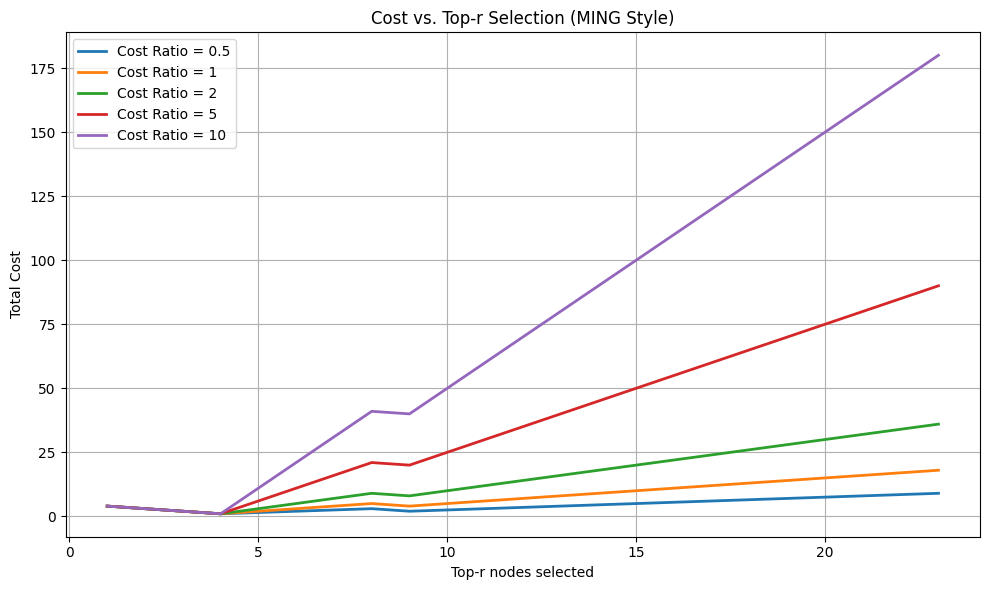

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure ming_probs and y_test are defined (from your model)
# Example: ming_probs = xgb_model.predict_proba(X_ming_test)[:, 1]

# Sort indices by descending predicted probability
sorted_indices = np.argsort(ming_probs)[::-1]
r_range = np.arange(1, len(ming_probs))

cost_ratios = [0.5, 1, 2, 5, 10]
cost_curves = {}

# Loop through each cost ratio and compute cost curve
for cost_ratio in cost_ratios:
    cost_values = []
    for r in r_range:
        preds_r = np.zeros_like(y_test)
        preds_r[sorted_indices[:r]] = 1

        fp = np.sum((preds_r == 1) & (y_test == 0))
        fn = np.sum((preds_r == 0) & (y_test == 1))
        cost = cost_ratio * fp + fn
        cost_values.append(cost)

    cost_curves[cost_ratio] = cost_values

# === Plotting ===
plt.figure(figsize=(10, 6))
for ratio, costs in cost_curves.items():
    plt.plot(r_range, costs, label=f'Cost Ratio = {ratio}', linewidth=2)

plt.xlabel('Top-r nodes selected')
plt.ylabel('Total Cost')
plt.title('Cost vs. Top-r Selection (MING Style)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
